In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
project_path = Path("/content/drive/MyDrive/ISL_GAN_FewShot_Project")
landmark_dir = project_path / "data" / "landmarks"
model_dir = project_path / "models" / "gan"
model_dir.mkdir(parents=True, exist_ok=True)

X_train = np.load(landmark_dir / "X_train.npy")
y_train = np.load(landmark_dir / "y_train.npy")

X_val = np.load(landmark_dir / "X_val.npy")
y_val = np.load(landmark_dir / "y_val.npy")

with open(landmark_dir / "class_mapping.json", "r") as f:
    mapping = json.load(f)

class_to_idx = mapping["class_to_idx"]
idx_to_class = {int(k): v for k, v in mapping["idx_to_class"].items()}
num_classes = len(class_to_idx)

print("Train shape:", X_train.shape, y_train.shape)
print("Classes:", num_classes)

Train shape: (170, 63) (170,)
Classes: 35


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Save scaler for later use
import joblib
joblib.dump(scaler, landmark_dir / "landmark_scaler.pkl")

print("Scaler saved.")

Scaler saved.


In [5]:
class LandmarkGANDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
BATCH_SIZE = 32

train_dataset = LandmarkGANDataset(X_train_scaled, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print("Train loader ready.")

Train loader ready.


In [7]:
class Generator(nn.Module):
    def __init__(self, noise_dim, num_classes, output_dim, embed_dim=32):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_vec = self.label_emb(labels)
        x = torch.cat([z, label_vec], dim=1)
        return self.net(x)

In [8]:
class Discriminator(nn.Module):
    def __init__(self, num_classes, input_dim, embed_dim=32):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)

        self.net = nn.Sequential(
            nn.Linear(input_dim + embed_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x, labels):
        label_vec = self.label_emb(labels)
        inp = torch.cat([x, label_vec], dim=1)
        return self.net(inp)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NOISE_DIM = 100
INPUT_DIM = X_train_scaled.shape[1]

G = Generator(NOISE_DIM, num_classes, INPUT_DIM).to(device)
D = Discriminator(num_classes, INPUT_DIM).to(device)

criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Generator and Discriminator initialized on:", device)

Generator and Discriminator initialized on: cuda


In [10]:
def save_checkpoint(model, path):
    torch.save(model.state_dict(), path)

def sample_noise(batch_size, noise_dim, device):
    return torch.randn(batch_size, noise_dim, device=device)

In [11]:
EPOCHS = 100
g_losses = []
d_losses = []

for epoch in range(EPOCHS):
    G.train()
    D.train()

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real_samples, labels in train_loader:
        real_samples = real_samples.to(device)
        labels = labels.to(device)

        batch_size = real_samples.size(0)

        # Real and fake targets
        real_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train Discriminator
        # -------------------------
        d_optimizer.zero_grad()

        real_pred = D(real_samples, labels)
        d_real_loss = criterion(real_pred, real_targets)

        z = sample_noise(batch_size, NOISE_DIM, device)
        fake_samples = G(z, labels)

        fake_pred = D(fake_samples.detach(), labels)
        d_fake_loss = criterion(fake_pred, fake_targets)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # -------------------------
        # Train Generator
        # -------------------------
        g_optimizer.zero_grad()

        z = sample_noise(batch_size, NOISE_DIM, device)
        gen_samples = G(z, labels)
        pred = D(gen_samples, labels)

        g_loss = criterion(pred, real_targets)
        g_loss.backward()
        g_optimizer.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    g_losses.append(epoch_g_loss / len(train_loader))
    d_losses.append(epoch_d_loss / len(train_loader))

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

save_checkpoint(G, model_dir / "generator.pth")
save_checkpoint(D, model_dir / "discriminator.pth")

print("GAN training completed.")

Epoch [1/100] G Loss: 0.6911 | D Loss: 1.3871
Epoch [2/100] G Loss: 0.6909 | D Loss: 1.3738
Epoch [3/100] G Loss: 0.6874 | D Loss: 1.3604
Epoch [4/100] G Loss: 0.6822 | D Loss: 1.3484
Epoch [5/100] G Loss: 0.6726 | D Loss: 1.3414
Epoch [6/100] G Loss: 0.6509 | D Loss: 1.3529
Epoch [7/100] G Loss: 0.6464 | D Loss: 1.3642
Epoch [8/100] G Loss: 0.6700 | D Loss: 1.3595
Epoch [9/100] G Loss: 0.6973 | D Loss: 1.3561
Epoch [10/100] G Loss: 0.7188 | D Loss: 1.3690
Epoch [11/100] G Loss: 0.7147 | D Loss: 1.3792
Epoch [12/100] G Loss: 0.7276 | D Loss: 1.3806
Epoch [13/100] G Loss: 0.7411 | D Loss: 1.3405
Epoch [14/100] G Loss: 0.7521 | D Loss: 1.3120
Epoch [15/100] G Loss: 0.7373 | D Loss: 1.3022
Epoch [16/100] G Loss: 0.7036 | D Loss: 1.3097
Epoch [17/100] G Loss: 0.6941 | D Loss: 1.3240
Epoch [18/100] G Loss: 0.6898 | D Loss: 1.3356
Epoch [19/100] G Loss: 0.7242 | D Loss: 1.3268
Epoch [20/100] G Loss: 0.7645 | D Loss: 1.2845
Epoch [21/100] G Loss: 0.7678 | D Loss: 1.2615
Epoch [22/100] G Loss:

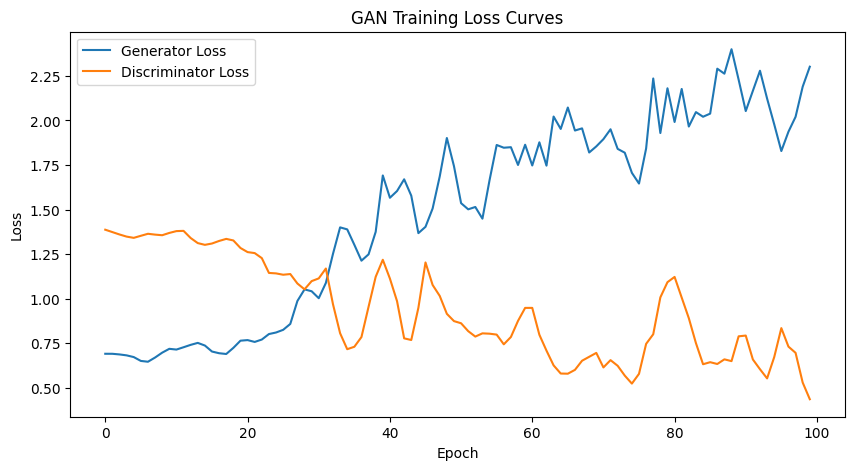

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss Curves")
plt.legend()
plt.show()

In [13]:
G.eval()

samples_per_class = 50
synthetic_X = []
synthetic_y = []

with torch.no_grad():
    for class_idx in range(num_classes):
        labels = torch.full((samples_per_class,), class_idx, dtype=torch.long, device=device)
        z = sample_noise(samples_per_class, NOISE_DIM, device)
        gen_samples = G(z, labels).cpu().numpy()

        synthetic_X.append(gen_samples)
        synthetic_y.append(np.full(samples_per_class, class_idx))

synthetic_X = np.vstack(synthetic_X)
synthetic_y = np.concatenate(synthetic_y)

print("Synthetic X shape:", synthetic_X.shape)
print("Synthetic y shape:", synthetic_y.shape)

Synthetic X shape: (1750, 63)
Synthetic y shape: (1750,)


In [14]:
# Convert back from [-1, 1] space to original feature space
synthetic_X_original = scaler.inverse_transform(synthetic_X)

np.save(landmark_dir / "X_synthetic.npy", synthetic_X_original)
np.save(landmark_dir / "y_synthetic.npy", synthetic_y)

synthetic_df = pd.DataFrame(synthetic_X_original, columns=[f"f{i}" for i in range(synthetic_X_original.shape[1])])
synthetic_df["class_name"] = [idx_to_class[i] for i in synthetic_y]

synthetic_csv = landmark_dir / "synthetic_landmarks.csv"
synthetic_df.to_csv(synthetic_csv, index=False)

print("Synthetic data saved to:")
print(synthetic_csv)

Synthetic data saved to:
/content/drive/MyDrive/ISL_GAN_FewShot_Project/data/landmarks/synthetic_landmarks.csv


In [15]:
sample_df = synthetic_df.head(5)
sample_df

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f54,f55,f56,f57,f58,f59,f60,f61,f62,class_name
0,0.000089,0.000237,0.000182,-0.018377,-0.058379,0.018906,0.098126,0.155630,0.024488,-0.178049,...,0.164837,0.274248,-0.170022,0.179913,0.325401,-0.155118,-0.045917,0.261972,-0.130088,1
1,0.000121,0.000350,0.000257,-0.019381,-0.051051,0.014291,0.076551,0.142032,0.025914,-0.141577,...,0.176870,0.274232,-0.168944,0.158861,0.326237,-0.152417,-0.028208,0.257221,-0.123655,1
2,0.000523,0.001389,0.001174,-0.007453,-0.047826,0.007288,0.068567,0.114742,0.009175,-0.122651,...,0.111425,0.227802,-0.155793,0.106884,0.296316,-0.144811,-0.050293,0.222133,-0.113734,1
3,0.000181,0.000526,0.000362,-0.015941,-0.048878,0.015814,0.074929,0.145486,0.014423,-0.125536,...,0.169703,0.252923,-0.172518,0.144975,0.319552,-0.146538,-0.048798,0.255433,-0.124274,1
4,0.000064,0.000222,0.000163,-0.011639,-0.051680,0.020316,0.095987,0.156978,0.024841,-0.166159,...,0.144303,0.277948,-0.172941,0.157972,0.335143,-0.169915,-0.029413,0.264854,-0.135220,1
